# 3b. Améliorations des Baselines

Ce notebook complète `03_baseline_models.ipynb` en couvrant les étapes manquantes du cahier des charges :

- **3.3** Gestion du déséquilibre : `class_weight` + **SMOTE**
- **4.2** Sélection de features : **SelectKBest (Mutual Information)** + **RFE**
- **5.1** Modèle additionnel : **LightGBM**
- **5.2** Recherche d'hyperparamètres : **GridSearchCV**

## Setup

In [1]:
import os, sys, json, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix, roc_auc_score)
import xgboost as xgb

try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_OK = True
except ImportError:
    IMBLEARN_OK = False
    print('imbalanced-learn non disponible — installez avec: pip install imbalanced-learn')

try:
    import lightgbm as lgb
    LGB_OK = True
except ImportError:
    LGB_OK = False
    print('lightgbm non disponible — installez avec: pip install lightgbm')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42
print('Bibliothèques chargées.')

Bibliothèques chargées.


## Chargement des données prétraitées

In [2]:
DATA_DIR = '../data/processed'
train = pd.read_csv(f'{DATA_DIR}/train_processed.csv')
val   = pd.read_csv(f'{DATA_DIR}/val_processed.csv')
test  = pd.read_csv(f'{DATA_DIR}/test_processed.csv')

X_train_text, y_train = train['cleaned_text'].astype(str), train['label_encoded'].values
X_val_text,   y_val   = val['cleaned_text'].astype(str),   val['label_encoded'].values
X_test_text,  y_test  = test['cleaned_text'].astype(str),  test['label_encoded'].values

print(f'Train: {len(X_train_text)} | Val: {len(X_val_text)} | Test: {len(X_test_text)}')
print('Distribution train:', dict(zip(*np.unique(y_train, return_counts=True))))

Train: 6420 | Val: 2140 | Test: 2140
Distribution train: {np.int64(0): np.int64(3060), np.int64(1): np.int64(3360)}


In [3]:
# Vectorisation TF-IDF (config standard)
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                              min_df=2, max_df=0.95, sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_text)
X_val   = vectorizer.transform(X_val_text)
X_test  = vectorizer.transform(X_test_text)
print(f'Shape TF-IDF train: {X_train.shape}')

Shape TF-IDF train: (6420, 10000)


---
## 3.3 Gestion du déséquilibre des classes

On compare 3 stratégies sur la **régression logistique** :
1. Baseline (sans correction)
2. `class_weight='balanced'`
3. SMOTE (sur-échantillonnage de la classe minoritaire)

In [4]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'precision': precision_score(y_te, pred),
        'recall': recall_score(y_te, pred),
        'f1': f1_score(y_te, pred),
        'roc_auc': roc_auc_score(y_te, proba) if proba is not None else None,
    }

imbalance_results = []

# 1. Baseline
imbalance_results.append(evaluate(
    'LR baseline',
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train, X_val, y_val))

# 2. class_weight balanced
imbalance_results.append(evaluate(
    'LR class_weight=balanced',
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    X_train, y_train, X_val, y_val))

# 3. SMOTE
if IMBLEARN_OK:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_tr_smote, y_tr_smote = smote.fit_resample(X_train, y_train)
    print(f'Avant SMOTE: {dict(zip(*np.unique(y_train, return_counts=True)))}')
    print(f'Après SMOTE: {dict(zip(*np.unique(y_tr_smote, return_counts=True)))}')
    imbalance_results.append(evaluate(
        'LR + SMOTE',
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        X_tr_smote, y_tr_smote, X_val, y_val))

df_imbalance = pd.DataFrame(imbalance_results)
df_imbalance

Avant SMOTE: {np.int64(0): np.int64(3060), np.int64(1): np.int64(3360)}
Après SMOTE: {np.int64(0): np.int64(3360), np.int64(1): np.int64(3360)}


,model,accuracy,precision,recall,f1,roc_auc
0,LR baseline,0.927103,0.934234,0.925893,0.930045,0.976704
1,LR class_weight=balanced,0.929439,0.942466,0.921429,0.931828,0.976778
2,LR + SMOTE,0.929907,0.941712,0.923214,0.932372,0.976946


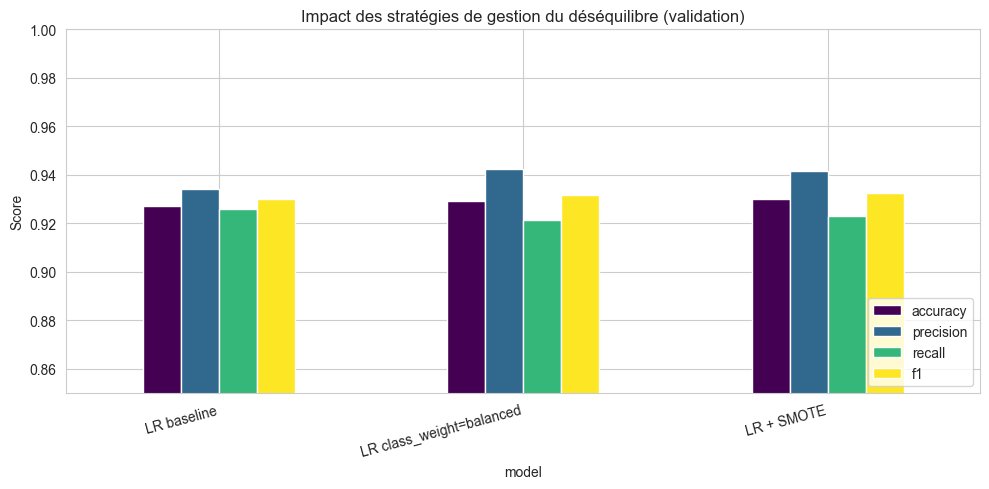

In [5]:
# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_imbalance.set_index('model')[['accuracy', 'precision', 'recall', 'f1']]
df_plot.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title("Impact des stratégies de gestion du déséquilibre (validation)")
ax.set_ylabel('Score'); ax.set_ylim(0.85, 1.0)
plt.xticks(rotation=15, ha='right'); plt.legend(loc='lower right')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/3b_imbalance_strategies.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4.2 Sélection de features

Deux méthodes appliquées sur la matrice TF-IDF :
- **SelectKBest** avec `mutual_info_classif`
- **RFE** (Recursive Feature Elimination) avec un estimateur LR rapide

In [6]:
# SelectKBest avec Mutual Information
K = 2000
t0 = time()
skb = SelectKBest(score_func=mutual_info_classif, k=K)
X_train_skb = skb.fit_transform(X_train, y_train)
X_val_skb   = skb.transform(X_val)
print(f'SelectKBest({K}) en {time()-t0:.1f}s | shape: {X_train_skb.shape}')

feat_names = np.array(vectorizer.get_feature_names_out())
top_mi = pd.DataFrame({
    'feature': feat_names[skb.get_support()],
    'mi_score': skb.scores_[skb.get_support()],
}).nlargest(20, 'mi_score')
top_mi

SelectKBest(2000) en 8.2s | shape: (6420, 2000)


,feature,mi_score
1645,the,0.406015
1177,of,0.338391
1752,to,0.308672
842,in,0.292676
163,and,0.224472
486,covid,0.214948
20,19,0.185524
446,coronavirus,0.182963
487,covid 19,0.179441
912,is,0.173615


In [7]:
# RFE avec LR (limité car coûteux : on travaille sur SelectKBest réduit)
t0 = time()
rfe = RFE(estimator=LogisticRegression(max_iter=300, random_state=RANDOM_STATE),
          n_features_to_select=500, step=0.2)
X_train_rfe = rfe.fit_transform(X_train_skb, y_train)
X_val_rfe   = rfe.transform(X_val_skb)
print(f'RFE en {time()-t0:.1f}s | shape: {X_train_rfe.shape}')

RFE en 0.1s | shape: (6420, 500)


In [8]:
# Comparaison performance avec / sans sélection
fs_results = []
fs_results.append(evaluate('LR — TF-IDF complet (10k)', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train, y_train, X_val, y_val))
fs_results.append(evaluate('LR — SelectKBest MI (2k)', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_skb, y_train, X_val_skb, y_val))
fs_results.append(evaluate('LR — RFE (500)', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), X_train_rfe, y_train, X_val_rfe, y_val))
df_fs = pd.DataFrame(fs_results)
df_fs

,model,accuracy,precision,recall,f1,roc_auc
0,LR — TF-IDF complet (10k),0.927103,0.934234,0.925893,0.930045,0.976704
1,LR — SelectKBest MI (2k),0.913084,0.922242,0.910714,0.916442,0.968912
2,LR — RFE (500),0.904206,0.914027,0.901786,0.907865,0.963663


---
## 5.1 Modèle additionnel : LightGBM

In [9]:
if LGB_OK:
    t0 = time()
    lgb_model = lgb.LGBMClassifier(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        max_depth=-1, min_child_samples=10, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(20, verbose=False)])
    pred = lgb_model.predict(X_val)
    proba = lgb_model.predict_proba(X_val)[:, 1]
    print(f'LightGBM entraîné en {time()-t0:.1f}s')
    print(classification_report(y_val, pred, target_names=['fake', 'real']))
    print(f'ROC-AUC: {roc_auc_score(y_val, proba):.4f}')
else:
    print('LightGBM non installé — section ignorée.')

LightGBM entraîné en 2.7s
              precision    recall  f1-score   support

        fake       0.92      0.93      0.92      1020
        real       0.94      0.92      0.93      1120

    accuracy                           0.93      2140
   macro avg       0.93      0.93      0.93      2140
weighted avg       0.93      0.93      0.93      2140

ROC-AUC: 0.9805


---
## 5.2 Recherche d'hyperparamètres : GridSearchCV

Recherche systématique sur 3 modèles (LR, SVM, XGBoost) avec validation croisée stratifiée 5-fold.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_results = {}

# --- Logistic Regression ---
t0 = time()
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid={'C': [0.1, 1.0, 5.0, 10.0], 'class_weight': [None, 'balanced']},
    cv=cv, scoring='f1', n_jobs=-1)
lr_grid.fit(X_train, y_train)
grid_results['LR'] = {'best_params': lr_grid.best_params_, 'best_cv_f1': lr_grid.best_score_,
                      'time_s': round(time()-t0, 1)}
print('LR best:', lr_grid.best_params_, '| F1 CV:', round(lr_grid.best_score_, 4))

LR best: {'C': 10.0, 'class_weight': 'balanced'} | F1 CV: 0.933


In [11]:
# --- LinearSVC ---
t0 = time()
svm_grid = GridSearchCV(
    LinearSVC(max_iter=2000, random_state=RANDOM_STATE),
    param_grid={'C': [0.1, 0.5, 1.0, 2.0], 'class_weight': [None, 'balanced']},
    cv=cv, scoring='f1', n_jobs=-1)
svm_grid.fit(X_train, y_train)
grid_results['SVM'] = {'best_params': svm_grid.best_params_, 'best_cv_f1': svm_grid.best_score_,
                       'time_s': round(time()-t0, 1)}
print('SVM best:', svm_grid.best_params_, '| F1 CV:', round(svm_grid.best_score_, 4))

SVM best: {'C': 0.5, 'class_weight': None} | F1 CV: 0.9352


In [12]:
# --- XGBoost (grille réduite — coûteux) ---
t0 = time()
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    param_grid={'n_estimators': [200, 400], 'max_depth': [4, 6], 'learning_rate': [0.05, 0.1]},
    cv=cv, scoring='f1', n_jobs=1)
xgb_grid.fit(X_train, y_train)
grid_results['XGBoost'] = {'best_params': xgb_grid.best_params_, 'best_cv_f1': xgb_grid.best_score_,
                           'time_s': round(time()-t0, 1)}
print('XGB best:', xgb_grid.best_params_, '| F1 CV:', round(xgb_grid.best_score_, 4))

XGB best: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400} | F1 CV: 0.9096


In [13]:
df_grid = pd.DataFrame(grid_results).T
df_grid

,best_params,best_cv_f1,time_s
LR,"{'C': 10.0, 'class_weight': 'balanced'}",0.933017,3.4
SVM,"{'C': 0.5, 'class_weight': None}",0.935207,0.3
XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.909578,265.2


---
## Évaluation finale sur le jeu de test des meilleurs modèles

In [14]:
best_models = {
    'LR_best': lr_grid.best_estimator_,
    'SVM_best': svm_grid.best_estimator_,
    'XGBoost_best': xgb_grid.best_estimator_,
}
if LGB_OK:
    best_models['LightGBM'] = lgb_model

test_results = []
for name, m in best_models.items():
    pred = m.predict(X_test)
    if hasattr(m, 'predict_proba'):
        proba = m.predict_proba(X_test)[:, 1]
    else:
        score = m.decision_function(X_test)
        proba = (score - score.min()) / (score.max() - score.min())
    test_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

df_test = pd.DataFrame(test_results).sort_values('f1', ascending=False)
df_test

,model,accuracy,precision,recall,f1,roc_auc
1,SVM_best,0.941121,0.948556,0.938393,0.943447,0.984431
0,LR_best,0.939252,0.947559,0.935714,0.941599,0.983991
3,LightGBM,0.927103,0.937387,0.922321,0.929793,0.980511
2,XGBoost_best,0.916355,0.934441,0.903571,0.918747,0.975313


In [15]:
# Sauvegarde
os.makedirs('../models', exist_ok=True)
df_test.to_csv('../reports/baseline_improvements_test.csv', index=False)
with open('../models/best_grid_params.json', 'w') as f:
    json.dump({k: {kk: (vv if not isinstance(vv, np.generic) else vv.item())
                   for kk, vv in v.items() if kk == 'best_params'}
               for k, v in grid_results.items()}, f, indent=2, default=str)
if LGB_OK:
    with open('../models/lightgbm.pkl', 'wb') as f:
        pickle.dump(lgb_model, f)
print('Résultats et modèles sauvegardés.')

Résultats et modèles sauvegardés.


## Résumé

Ce notebook complète les étapes manquantes du cahier des charges :

| Étape | Méthode | Couvert |
|---|---|---|
| 3.3 | class_weight + SMOTE | ✅ |
| 4.2 | SelectKBest (MI) + RFE | ✅ |
| 5.1 | LightGBM | ✅ |
| 5.2 | GridSearchCV + StratifiedKFold | ✅ |